<a href="https://colab.research.google.com/github/cpython-projects/python_da_17_03_26/blob/main/lesson_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/cpython-projects/python_da_17_03_26/refs/heads/main/kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

# Групування даних з `groupby()`

## Що таке `groupby()`

Метод `groupby()` дозволяє згрупувати дані за одним або кількома критеріями для подальшого узагальнення (агрегації).

**Загальна формула:**

```python
df.groupby(ключ)[поля].агрегуюча_функція()
```

## Сценарії використання

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [3]:
df.columns.to_list()

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

In [5]:
# Групування по одному полю — одна метрика
df.condition.unique()

array([3, 5, 4, 1, 2])

<Axes: >

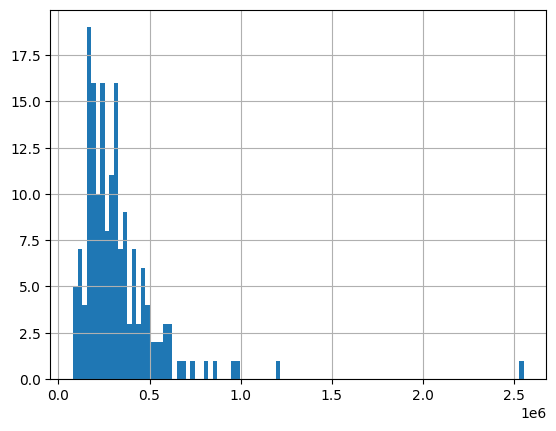

In [14]:
df[df.condition == 2].price.hist(bins=100)

In [16]:
res = df.groupby('condition')['price'].median()
res

,price
condition,
1,262500.0
2,279000.0
3,450000.0
4,440000.0
5,526000.0


In [17]:
type(res)

pandas.core.series.Series

In [18]:
res = df.groupby('condition')['price'].median().reset_index()
res

,condition,price
0,1,262500.0
1,2,279000.0
2,3,450000.0
3,4,440000.0
4,5,526000.0


In [20]:
# Групування по одному полю — кілька метрик
res = df.groupby('condition')['price'].agg(['mean', 'median']).reset_index()
res

,condition,mean,median
0,1,334431.666667,262500.0
1,2,327287.145349,279000.0
2,3,542012.578148,450000.0
3,4,521200.390033,440000.0
4,5,612418.089359,526000.0


In [22]:
# Групування по кількох полях
res = df.groupby(['condition', 'bedrooms'])['price'].agg(['mean', 'median'])
res

mean     median
condition bedrooms                         
1         0         1.420000e+05   142000.0
          1         2.855000e+05   221000.0
          2         2.772917e+05   245000.0
          3         4.007438e+05   261000.0
          4         4.457500e+05   434000.0
          6         4.325000e+05   432500.0
2         0         2.280000e+05   228000.0
          1         2.450000e+05   250000.0
          2         2.759067e+05   255000.0
          3         2.963365e+05   235000.0
          4         4.733883e+05   375000.0
          5         2.355000e+05   235500.0
          6         5.248167e+05   619500.0
3         0         4.813600e+05   329975.0
          1         3.135745e+05   309975.0
          2         4.012794e+05   371000.0
          3         4.671847e+05   415700.0
          4         6.335218e+05   549950.0
          5         8.130543e+05   633000.0
          6         7.866955e+05   652500.0
          7         9.179944e+05   727160.0
          8         7.920000e+05   637500.0
          9         8.939998e+05   817000.0
          10        1.148000e+06  1148000.0
          11        5.200000e+05   520000.0
4         0         1.399500e+05   139950.0
          1         3.480948e+05   308475.0
          2         4.059846e+05   389050.0
          3         4.543136e+05   395000.0
          4         6.159941e+05   530000.0
          5         7.080780e+05   573725.0
          6         8.747552e+05   611000.0
          7         8.505730e+05   597157.0
          8         9.200000e+05   680000.0
          10        6.550000e+05   655000.0
5         1         3.151792e+05   275500.0
          2         4.250840e+05   391650.0
          3         5.191837e+05   456075.0
          4         7.181036e+05   620000.0
          5         8.269887e+05   660500.0
          6         9.623078e+05   735000.0
          7         1.385000e+06   805000.0
          8         2.635000e+06  2635000.0
          33        6.400000e+05   640000.0

## `reset_index()`

Після `groupby()` індексом стає групувальне поле (або поля). Щоб зробити з них **звичайні колонки**, потрібно:

```python
.reset_index()
```

Інакше графіки чи подальша робота будуть ускладнені.

## Задача: обчислити:

* середню ціну (`price`)
* кількість оголошень (`count`)
* медіанну площу (`sqft_living`)
  по кожному району

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [24]:
df['zipcode'] = df.zipcode.astype('category')

In [26]:
df.groupby('zipcode')['price'].agg(['mean', 'count'])

,mean,count
zipcode,,
98001,2.808047e+05,362
98002,2.342840e+05,199
98003,2.941113e+05,280
98004,1.355927e+06,317
98005,8.101649e+05,168
...,...,...
98177,6.761854e+05,255
98178,3.106128e+05,262
98188,2.890783e+05,136


In [27]:
df.groupby('zipcode')['sqft_living'].median()

,sqft_living
zipcode,
98001,1822.0
98002,1570.0
98003,1780.0
98004,2660.0
98005,2505.0
...,...
98177,2120.0
98178,1725.0
98188,1690.0


# Агрегації `.agg()` в Pandas

## Навіщо потрібні агрегації?

Агрегація — це зведення (узагальнення) числових значень:

| Приклади запитань                      | Агрегація  |
| -------------------------------------- | ---------- |
| Яка середня площа будинків в районі Х?     | `mean()`   |
| Скільки будинків виставлено у Y? | `count()`  |
| Яка максимальна ціна у 1 bedrooms?         | `max()`    |
| Яка медіанна кухня у 3-bedrooms?      | `median()` |

---

## Синтаксис `.agg()` — на одному або кількох полях

```python
df.agg({'col1': 'mean', 'col2': 'max'})
```

Або на одній колонці:

```python
df['price'].agg(['mean', 'median', 'std'])
```

---

## Комбінування з `groupby()`

```python
df.groupby('zipcode').agg({
    'price': ['mean', 'median', 'min', 'max'],
    'sqft_living': 'mean'
})
```

У результаті — **ієрархічний заголовок колонок (MultiIndex)** → бажано `.reset_index()` та перейменувати колонки.

In [28]:
df.groupby('zipcode').agg({
    'price': ['mean', 'median', 'min', 'max'],
    'sqft_living': 'mean'
})

price                                  sqft_living
                 mean     median       min        max         mean
zipcode                                                           
98001    2.808047e+05   260000.0  100000.0   850000.0  1900.856354
98002    2.342840e+05   235000.0   95000.0   389000.0  1627.743719
98003    2.941113e+05   267475.0  128000.0   950000.0  1928.882143
98004    1.355927e+06  1150000.0  425000.0  7062500.0  2909.022082
98005    8.101649e+05   765475.0  400000.0  1960000.0  2656.803571
...               ...        ...       ...        ...          ...
98177    6.761854e+05   554000.0  245560.0  3800000.0  2323.333333
98178    3.106128e+05   278277.0   90000.0  1700000.0  1729.351145
98188    2.890783e+05   264000.0  110000.0   707000.0  1802.772059
98198    3.028789e+05   265000.0   95000.0  1350000.0  1745.360714
98199    7.918208e+05   689800.0  323000.0  3200000.0  2161.798107

[70 rows x 5 columns]

In [ ]:
summary = df[['price', 'sqft_living']].agg(
    ['mean', 'median', 'std', 'min', 'max', 'count']
).round(1).reset_index()

summary


,index,price,sqft_living
0,mean,540088.1,2079.9
1,median,450000.0,1910.0
2,std,367127.2,918.4
3,min,75000.0,290.0
4,max,7700000.0,13540.0
5,count,21613.0,21613.0


In [30]:
df.groupby(['condition'])['price'].agg(['median', 'mean', 'count'])

,median,mean,count
condition,,,
1,262500.0,334431.666667,30
2,279000.0,327287.145349,172
3,450000.0,542012.578148,14031
4,440000.0,521200.390033,5679
5,526000.0,612418.089359,1701


In [31]:
# T - transpose
df.groupby(['condition'])['price'].agg(['median', 'mean', 'count']).T.round(1)

condition,1,2,3,4,5
median,262500.0,279000.0,450000.0,440000.0,526000.0
mean,334431.7,327287.1,542012.6,521200.4,612418.1
count,30.0,172.0,14031.0,5679.0,1701.0


## Нюанси

| Питання                       | Коментар                                     |
| ----------------------------- | -------------------------------------------- |
| `NaN`                         | Ігноруються у функціях агрегування           |
| `.agg()` після `groupby()`    | Повертає MultiIndex → `.reset_index()`       |
| `std`, `min`, `max`, `median` | Обчислюються лише для числових               |
| Для bool                      | Можна використовувати `mean()` — доля `True` |

---

# Зведені таблиці (`pivot_table`)

## Що таке `pivot_table`

`pivot_table()` — це розширений варіант `groupby`, який дозволяє:

* Зробити зведену таблицю по кількох категоріях
* Розмістити одну категорію по рядках, іншу по стовпцях
* Одразу застосувати агрегуючу функцію
* Аналог Excel PivotTable!

---

## Синтаксис

```python
pd.pivot_table(
    data=df,
    values='метрика',
    index='рядки',
    columns='стовпці',
    aggfunc='функція'
)
```

In [33]:
# Приклад: середня ціна по містах і кількості кімнат
pd.pivot_table(
    df,
    values='price',
    index='zipcode',
    columns='bedrooms',
    aggfunc='mean'
).round(1)

bedrooms,0,1,2,3,4,5,6,7,8,9,10,11,33
zipcode,,,,,,,,,,,,,
98001,139950.0,169333.3,217795.5,256070.2,325339.6,318516.2,230000.0,NaN,NaN,NaN,NaN,NaN,NaN
98002,NaN,116500.0,187162.4,224578.7,261097.8,270600.0,317750.0,NaN,NaN,NaN,NaN,NaN,NaN
98003,NaN,360000.0,215893.5,265377.2,344253.9,428175.0,350500.0,NaN,NaN,NaN,NaN,NaN,NaN
98004,NaN,NaN,810607.1,1014348.7,1422505.1,1865356.2,1223000.0,2300000.0,1900000.0,NaN,1148000.0,NaN,NaN
98005,NaN,NaN,780000.0,692642.7,865821.2,880197.0,967166.7,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
98177,NaN,319000.0,486912.9,650899.5,698135.0,953830.5,1084660.0,NaN,NaN,NaN,NaN,NaN,NaN
98178,NaN,231000.0,258322.6,274831.3,366566.3,383477.2,455333.3,NaN,NaN,NaN,NaN,NaN,NaN
98188,NaN,NaN,231616.7,260233.6,329309.1,348768.2,383700.0,NaN,NaN,NaN,NaN,NaN,NaN


## Додаткові параметри

| Параметр                     | Значення            |
| ---------------------------- | ------------------- |
| `fill_value`                 | чим заповнити `NaN` |
| `margins=True`               | додати підсумки     |
| `aggfunc=['mean', 'median']` | кілька функцій      |


In [36]:
# Приклад: середня ціна по містах і кількості кімнат
pd.pivot_table(
    df,
    values='price',
    index='bedrooms',
    columns='condition',
    aggfunc=['mean', 'median'],
    fill_value=0
).round(1)

mean                                              median  \
condition         1         2          3         4          5         1   
bedrooms                                                                  
0          142000.0  228000.0   481360.0  139950.0        0.0  142000.0   
1          285500.0  245000.0   313574.5  348094.8   315179.2  221000.0   
2          277291.7  275906.7   401279.4  405984.6   425084.0  245000.0   
3          400743.8  296336.5   467184.7  454313.6   519183.7  261000.0   
4          445750.0  473388.3   633521.8  615994.1   718103.6  434000.0   
5               0.0  235500.0   813054.3  708078.0   826988.7       0.0   
6          432500.0  524816.7   786695.5  874755.2   962307.8  432500.0   
7               0.0       0.0   917994.4  850573.0  1385000.0       0.0   
8               0.0       0.0   792000.0  920000.0  2635000.0       0.0   
9               0.0       0.0   893999.8       0.0        0.0       0.0   
10              0.0       0.0  1148000.0  655000.0        0.0       0.0   
11              0.0       0.0   520000.0       0.0        0.0       0.0   
33              0.0       0.0        0.0       0.0   640000.0       0.0   

                                                     
condition         2          3         4          5  
bedrooms                                             
0          228000.0   329975.0  139950.0        0.0  
1          250000.0   309975.0  308475.0   275500.0  
2          255000.0   371000.0  389050.0   391650.0  
3          235000.0   415700.0  395000.0   456075.0  
4          375000.0   549950.0  530000.0   620000.0  
5          235500.0   633000.0  573725.0   660500.0  
6          619500.0   652500.0  611000.0   735000.0  
7               0.0   727160.0  597157.0   805000.0  
8               0.0   637500.0  680000.0  2635000.0  
9               0.0   817000.0       0.0        0.0  
10              0.0  1148000.0  655000.0        0.0  
11              0.0   520000.0       0.0        0.0  
33              0.0        0.0       0.0   640000.0

# Частотні таблиці — `pd.crosstab()`

## Що таке `crosstab`

`pd.crosstab()` — це спосіб підрахунку **кількості випадків** для комбінацій категоріальних змінних.

## Синтаксис

```python
pd.crosstab(index=df['рядки'], columns=df['стовпці'])
```

In [ ]:
df.columns.to_list()

['id',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15',
 'area_category',
 'area_auto_category']

In [37]:
df.yr_renovated.unique()

array([   0, 1991, 2002, 2010, 1999, 1992, 2013, 1994, 1978, 2005, 2008,
       2003, 1984, 1954, 2014, 2011, 1974, 1983, 1945, 1990, 1988, 1957,
       1977, 1981, 1995, 2000, 1998, 1970, 1989, 2004, 1986, 2009, 2007,
       1987, 1973, 2006, 1985, 2001, 1980, 1971, 1979, 1997, 1950, 1969,
       1948, 2015, 1968, 2012, 1963, 1951, 1993, 1962, 1996, 1972, 1953,
       1955, 1982, 1956, 1940, 1976, 1946, 1975, 1958, 1964, 1959, 1960,
       1967, 1965, 1934, 1944])

In [38]:
df['is_renovated'] = df.yr_renovated >= 1990

In [39]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,is_renovated
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650,False
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639,True
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062,False
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000,False
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,1530.0,0,2009,0,98103,47.6993,-122.346,1530,1509,False
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,2310.0,0,2014,0,98146,47.5107,-122.362,1830,7200,False
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,1020.0,0,2009,0,98144,47.5944,-122.299,1020,2007,False
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,1600.0,0,2004,0,98027,47.5345,-122.069,1410,1287,False


In [40]:
# Приклад: скільки якісних будинків було оновлено
pd.crosstab(index=df.grade, columns=df.is_renovated)

is_renovated,False,True
grade,,
1,1,0
3,3,0
4,29,0
5,239,3
6,1990,48
7,8781,200
8,5866,202
9,2489,126
10,1089,45


## Нюанси

| Питання                            | Коментар                              |
| ---------------------------------- | ------------------------------------- |
| `NaN` у категоріях                 | не враховуються                       |
| `normalize='index'`                | показує **частки** замість кількостей |
| Можна додати `values=`, `aggfunc=` | як у pivot\_table                     |

---

In [44]:
# Приклад: скільки якісних будинків було оновлено
pd.crosstab(index=df.grade, columns=df.is_renovated, normalize='columns').round(2) * 100

is_renovated,False,True
grade,,
1,0.0,0.0
3,0.0,0.0
4,0.0,0.0
5,1.0,0.0
6,9.0,8.0
7,42.0,31.0
8,28.0,32.0
9,12.0,20.0
10,5.0,7.0


# `resample()` — агрегування за датами

## Що таке `resample`

`resample()` — це аналог `groupby()` **по часу**, який працює з колонкою `datetime`.

Необхідно:

* мати колонку типу `datetime64[ns]`
* встановити її як **індекс**

---

## Синтаксис:

```python
df.resample('період')['метрика'].agg(функція)
```


### Базові часові одиниці

| Частота     | Alias             | Опис             |
| ----------- | ----------------- | ---------------- |
| Day         | `'D'`             | календарний день |
| Hour        | `'H'` або `'h'`   | година           |
| Minute      | `'T'` або `'min'` | хвилина          |
| Second      | `'S'` або `'s'`   | секунда          |
| Millisecond | `'ms'`            | мілісекунда      |
| Microsecond | `'us'`            | мікросекунда     |
| Nanosecond  | `'ns'`            | наносекунда      |

---

### Бізнес-час і бізнес-дні

| Частота                  | Alias   | Опис                                                 |
| ------------------------ | ------- | ---------------------------------------------------- |
| BDay / BusinessDay       | `'B'`   | бізнес-день (пн–пт)                                  |
| CDay / CustomBusinessDay | `'C'`   | кастомний бізнес-день (за користувацьким календарем) |
| BusinessHour             | `'bh'`  | бізнес-година                                        |
| CustomBusinessHour       | `'cbh'` | кастомна бізнес-година                               |

---

### Тижні

| Частота         | Alias    | Опис                                           |
| --------------- | -------- | ---------------------------------------------- |
| Week            | `'W'`    | тиждень, можна якір на день (`W-MON`, `W-FRI`) |
**Приклади**

* `'W'` — тиждень, кінець у неділю
* `'W-MON'` — тиждень з кінцем у понеділок

---

### Місячні частоти

| Частота        | Alias              | Опис                            |
| -------------- | ------------------ | ------------------------------- |
| MonthEnd       | `'M'` або `'ME'`   | кінець календарного місяця      |
| MonthBegin     | `'MS'`             | початок місяця                  |
| BMonthEnd      | `'BM'` або `'BME'` | бізнес-кінець місяця            |
| BMonthBegin    | `'BMS'`            | бізнес-початок місяця           |

---

### Квартали

| Частота       | Alias              | Опис                                    |
| ------------- | ------------------ | --------------------------------------- |
| QuarterEnd    | `'Q'` або `'QE'`   | кінець календарного кварталу            |
| QuarterBegin  | `'QS'`             | початок кварталу                        |
| BQuarterEnd   | `'BQ'` або `'BQE'` | бізнес-кінець кварталу                  |
| BQuarterBegin | `'BQS'`            | бізнес-початок кварталу                 |

**Приклади**

* `'Q-MAR'` — квартал, що закінчується у березні
* `'QS-APR'` — квартал починається у квітні

---

### Річні частоти

| Частота    | Alias                   | Опис                       |
| ---------- | ----------------------- | -------------------------- |
| YearEnd    | `'A'` або `'YE'`        | кінець календарного року   |
| YearBegin  | `'AS'`, `'YS'`, `'BYS'` | початок року               |
| BYearEnd   | `'BA'`, `'BYE'`         | бізнес-кінець року         |
| BYearBegin | `'BAS'`, `'BYS'`        | бізнес-початок року        |


**Приклади**

* `'A-DEC'` — рік закінчується у грудні
* `'AS-JUL'` — рік починається у липні

In [45]:
# Підготовка даних
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   id             21613 non-null  int64   
 1   date           21613 non-null  object  
 2   price          21613 non-null  float64 
 3   bedrooms       21613 non-null  int64   
 4   bathrooms      21613 non-null  float64 
 5   sqft_living    21613 non-null  int64   
 6   sqft_lot       21613 non-null  int64   
 7   floors         21613 non-null  float64 
 8   waterfront     21613 non-null  int64   
 9   view           21613 non-null  int64   
 10  condition      21613 non-null  int64   
 11  grade          21613 non-null  int64   
 12  sqft_above     21611 non-null  float64 
 13  sqft_basement  21613 non-null  int64   
 14  yr_built       21613 non-null  int64   
 15  yr_renovated   21613 non-null  int64   
 16  zipcode        21613 non-null  category
 17  lat            21613 non-null  

In [46]:
df['date'] = pd.to_datetime(df.date, format='%Y%m%dT%H%M%S', errors='coerce')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,is_renovated
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650,False
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639,True
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062,False
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000,False
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,2014-05-21,360000.0,3,2.50,1530,1131,3.0,0,0,...,1530.0,0,2009,0,98103,47.6993,-122.346,1530,1509,False
21609,6600060120,2015-02-23,400000.0,4,2.50,2310,5813,2.0,0,0,...,2310.0,0,2014,0,98146,47.5107,-122.362,1830,7200,False
21610,1523300141,2014-06-23,402101.0,2,0.75,1020,1350,2.0,0,0,...,1020.0,0,2009,0,98144,47.5944,-122.299,1020,2007,False
21611,291310100,2015-01-16,400000.0,3,2.50,1600,2388,2.0,0,0,...,1600.0,0,2004,0,98027,47.5345,-122.069,1410,1287,False


In [ ]:
df.set_index(df.date, inplace=True)

In [48]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,is_renovated
date,,,,,,,,,,,,,,,,,,,,,
2014-10-13,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650,False
2014-12-09,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639,True
2015-02-25,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062,False
2014-12-09,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000,False
2015-02-18,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-05-21,263000018,2014-05-21,360000.0,3,2.50,1530,1131,3.0,0,0,...,1530.0,0,2009,0,98103,47.6993,-122.346,1530,1509,False
2015-02-23,6600060120,2015-02-23,400000.0,4,2.50,2310,5813,2.0,0,0,...,2310.0,0,2014,0,98146,47.5107,-122.362,1830,7200,False
2014-06-23,1523300141,2014-06-23,402101.0,2,0.75,1020,1350,2.0,0,0,...,1020.0,0,2009,0,98144,47.5944,-122.299,1020,2007,False


In [49]:
df.sort_index(inplace=True)

In [50]:
# Приклад: середня ціна будинка по місяцях
df.resample('M')['price'].mean()

,price
date,
2014-05-31,548080.276584
2014-06-30,558002.199541
2014-07-31,544788.764360
2014-08-31,536445.276804
2014-09-30,529253.821871
2014-10-31,539026.971778
2014-11-30,521961.009213
2014-12-31,524461.866757
2015-01-31,525870.889571


In [51]:
df.resample('Q')['price'].mean()

,price
date,
2014-06-30,553558.947315
2014-09-30,537405.582278
2014-12-31,529467.025840
2015-03-31,528655.415550
2015-06-30,561004.517205


In [53]:
# Візуалізація: динаміка середньої ціни по місяцях
res = df.resample('M')['price'].mean()
px.line(
    res
).show()

In [55]:
# Кількість угод по тижнях
res = df.resample('W')['price'].count()

In [56]:
# Візуалізація: кількість угод по тижнях
px.line(
    res
).show()

## Навіщо аналітику `resample`

| Що дізнаємось                         | Як це корисно                       |
| ------------------------------------- | ----------------------------------- |
| Сезонність ринку                      | порівняння цін по місяцях/роках     |
| Активність користувачів               | по кількості оголошень              |
| Аналіз впливу подій (інфляція, війна) | тренди по кварталах                 |
| Маркетинг                             | коли зростає інтерес до нерухомості |

---

## Нюанси

| Проблема          | Рішення                                 |
| ----------------- | --------------------------------------- |
| Не дата в індексі | `.set_index('datetime')`                |
| Пропущені періоди | Автоматично створюються `NaN`           |
| Смугастий графік  | Використовуйте `'M'`, `'Q'`, а не `'D'` |
| Великі значення   | Обрізати викиди перед побудовою         |

---

# `pd.cut()` — групування числових значень у категорії

## Що таке `cut`

`cut()` розбиває числову колонку на **інтервали (бінінг)**. Наприклад, можна створити категорії будинків:

* до 40 м² → «малий»
* 40–80 м² → «середній»
* понад 80 м² → «великий»

Це корисно для:

* **аналізу розподілу** (гістограми, pie charts)
* **порівнянь середніх цін між групами**
* **створення сегментів**

---

## Синтаксис

```python
pd.cut(Series, bins, labels=..., include_lowest=True)
```

| Параметр         | Значення                         |
| ---------------- | -------------------------------- |
| `bins`           | кількість або список меж         |
| `labels`         | імена категорій                  |
| `include_lowest` | включити нижню межу в перший бін |

---

In [58]:
df.sqft_living.min(), df.sqft_living.max()

(290, 13540)

In [60]:
# Приклад: Розбиття будитнків за площею
df['area_category'] = pd.cut(
    df.sqft_living,
    bins=[0, 500, 1000, df.sqft_living.max()],
    labels=['small', 'medium', 'large']
    )

df.groupby('area_category')['price'].count()

,price
area_category,
small,18
medium,1476
large,20119


In [61]:
# Альтернатива: qcut() — автоматичне розбиття на квантилі
# Корисно, коли хочемо однакову кількість спостережень у групі, а не однакову ширину інтервалу.

# Приклад: Розбиття будитнків за площею
df['area_category'] = pd.qcut(
    df.sqft_living,
    q=3,
    labels=['small', 'medium', 'large']
    )

df.groupby('area_category')['price'].count()

,price
area_category,
small,7233
medium,7188
large,7192


## Навіщо аналітику `cut` і `qcut`

| Задача                             | Рішення                |
| ---------------------------------- | ---------------------- |
| Побудова сегментів                 | `cut` або `qcut`       |
| Когортний аналіз (покоління, ціна) | `cut` по даті або ціні |
| Спрощення числових фіч             | категоризація          |
| Візуалізація (pie, bar, boxplot)   | категорії зручніші     |

---

## Типові помилки

| Проблема                          | Рішення                                   |
| --------------------------------- | ----------------------------------------- |
| Значення на межі не включене      | `include_lowest=True`                     |
| Некоректні категорії              | задати `labels` вручну або перевірити     |
| Багато унікальних значень у `cut` | замість `cut` — використовувати `qcut`    |
| Нерівномірні категорії            | вручну задати `bins`, якщо треба контроль |

---